# Exploratory Data Analysis — UCI Online Retail II

**Project:** Customer Lifetime Value & Churn Engine
**Notebook:** `01_eda_online_retail.ipynb`
**Inputs:**
- `data/02_intermediate/transactions_raw.parquet` — both yearly sheets parsed into one frame, **before** cleaning (used to study missingness).
- `data/03_primary/transactions.parquet` — cleaned, analysis-ready transactions.

## Objectives
1. Understand the shape, schema and quality of the data.
2. **Investigate missingness** and determine whether missing `Customer ID` is
   **MCAR / MAR / MNAR**.
3. Understand the **distributions** of the key variables (line and customer level).
4. Surface patterns that will drive **feature engineering** and the churn model.

## 0. Setup

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 11


def find_project_root(start: Path) -> Path:
    for parent in [start.resolve(), *start.resolve().parents]:
        if (parent / "pyproject.toml").exists():
            return parent
    raise FileNotFoundError("Could not locate project root (pyproject.toml)")


PROJECT_ROOT = find_project_root(Path.cwd())
RAW_PATH = PROJECT_ROOT / "data/02_intermediate/transactions_raw.parquet"
CLEAN_PATH = PROJECT_ROOT / "data/03_primary/transactions.parquet"
print("project root :", PROJECT_ROOT)
print("raw exists   :", RAW_PATH.exists())
print("clean exists :", CLEAN_PATH.exists())

project root : /Users/Hirujan/Documents/GitHub/Customer-Lifetime-Value-and-Churn-Analysis
raw exists   : True
clean exists : True


## 1. Load data

In [2]:
raw = pd.read_parquet(RAW_PATH)
clean = pd.read_parquet(CLEAN_PATH)

print(f"raw   : {raw.shape[0]:>10,} rows x {raw.shape[1]} columns  (pre-cleaning)")
print(f"clean : {clean.shape[0]:>10,} rows x {clean.shape[1]} columns  (post-cleaning)")
print(f"rows dropped by cleaning: {len(raw) - len(clean):,}  ({(len(raw)-len(clean))/len(raw)*100:.2f}%)")
raw.head(5)

raw   :  1,067,371 rows x 9 columns  (pre-cleaning)
clean :    808,723 rows x 14 columns  (post-cleaning)
rows dropped by cleaning: 258,648  (24.23%)


,invoice_no,stock_code,description,quantity,invoice_date,unit_price,customer_id,country,source_sheet
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,"13,085.00",United Kingdom,Year 2009-2010
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,Year 2009-2010
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,"13,085.00",United Kingdom,Year 2009-2010
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,"13,085.00",United Kingdom,Year 2009-2010
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,"13,085.00",United Kingdom,Year 2009-2010


## 2. Schema and column profiles

`transactions_raw` uses the canonical column names produced by the ingestion
pipeline. Note that only the raw layer still contains rows without a customer.

In [3]:
schema = pd.DataFrame(
    {
        "dtype": raw.dtypes.astype(str),
        "n_unique": raw.nunique(dropna=True),
        "n_missing": raw.isna().sum(),
        "pct_missing": (raw.isna().mean() * 100).round(2),
    }
)
schema

,dtype,n_unique,n_missing,pct_missing
invoice_no,string,53628,0,0.00
stock_code,string,5305,0,0.00
description,string,5698,4382,0.41
quantity,int64,1057,0,0.00
invoice_date,datetime64[ns],47635,0,0.00
unit_price,float64,2807,0,0.00
customer_id,float64,5942,243007,22.77
country,string,43,0,0.00
source_sheet,string,2,0,0.00


## 3. Missing values

Missing data falls into three classical regimes:

| Regime | Meaning | Consequence |
| ------ | ------- | ----------- |
| **MCAR** | Missingness is independent of everything | Dropping rows is unbiased |
| **MAR** | Missingness depends on **observed** variables | Dropping rows is biased unless modelled |
| **MNAR** | Missingness depends on the **unobserved value itself** | Dropping rows introduces systematic bias |

`Customer ID` is the critical field: without it a transaction cannot be
attributed to a customer, so those rows are removed in the `transactions`
(downstream) dataset. Whether that removal is safe depends on **why** the ID is
missing.

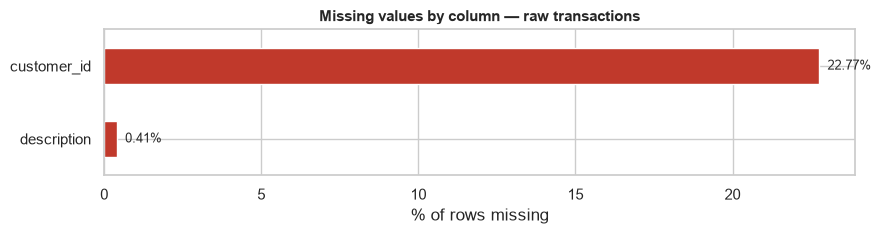

Rows with missing Customer ID : 243,007
Share of all rows             : 22.77%


In [4]:
missing_pct = (raw.isna().mean() * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

fig, ax = plt.subplots(figsize=(9, max(2.5, 0.5 * len(missing_pct))))
missing_pct.plot(kind="barh", ax=ax, color="#c0392b")
ax.invert_yaxis()
ax.set_xlabel("% of rows missing")
ax.set_title("Missing values by column — raw transactions")
for i, v in enumerate(missing_pct.values):
    ax.text(v, i, f"  {v:.2f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

print(f"Rows with missing Customer ID : {int(raw['customer_id'].isna().sum()):,}")
print(f"Share of all rows             : {raw['customer_id'].isna().mean()*100:.2f}%")

## 4. Is missing `Customer ID` MCAR, MAR or MNAR?

We cannot observe the *identity* of a missing-customer purchase, but we **can**
test whether missingness depends on variables we do observe. If it does, the
data are at least **not MCAR**.

In [5]:
raw = raw.assign(
    is_cancellation=raw["invoice_no"].astype(str).str.upper().str.startswith("C"),
    invoice_date=pd.to_datetime(raw["invoice_date"]),
    line_revenue=pd.to_numeric(raw["quantity"], errors="coerce")
    * pd.to_numeric(raw["unit_price"], errors="coerce"),
    missing_customer=raw["customer_id"].isna(),
)
raw["invoice_month"] = raw["invoice_date"].dt.to_period("M").astype(str)
print("derived helper columns added")
raw[["invoice_no", "is_cancellation", "line_revenue", "missing_customer"]].head()

derived helper columns added


,invoice_no,is_cancellation,line_revenue,missing_customer
0,489434,False,83.40,False
1,489434,False,81.00,False
2,489434,False,81.00,False
3,489434,False,100.80,False
4,489434,False,30.00,False


### 4.1 Missingness by country

In [6]:
by_country = raw.groupby("country").agg(
    n_rows=("missing_customer", "size"),
    n_missing=("missing_customer", "sum"),
)
by_country["pct_missing"] = by_country["n_missing"] / by_country["n_rows"] * 100
by_country = by_country.sort_values("n_rows", ascending=False)
by_country.head(15)

,n_rows,n_missing,pct_missing
country,,,
United Kingdom,981330,240029,24.46
EIRE,17866,1671,9.35
Germany,17624,0,0.00
France,14330,128,0.89
Netherlands,5140,0,0.00
Spain,3811,0,0.00
Switzerland,3189,125,3.92
Belgium,3123,0,0.00
Portugal,2620,116,4.43


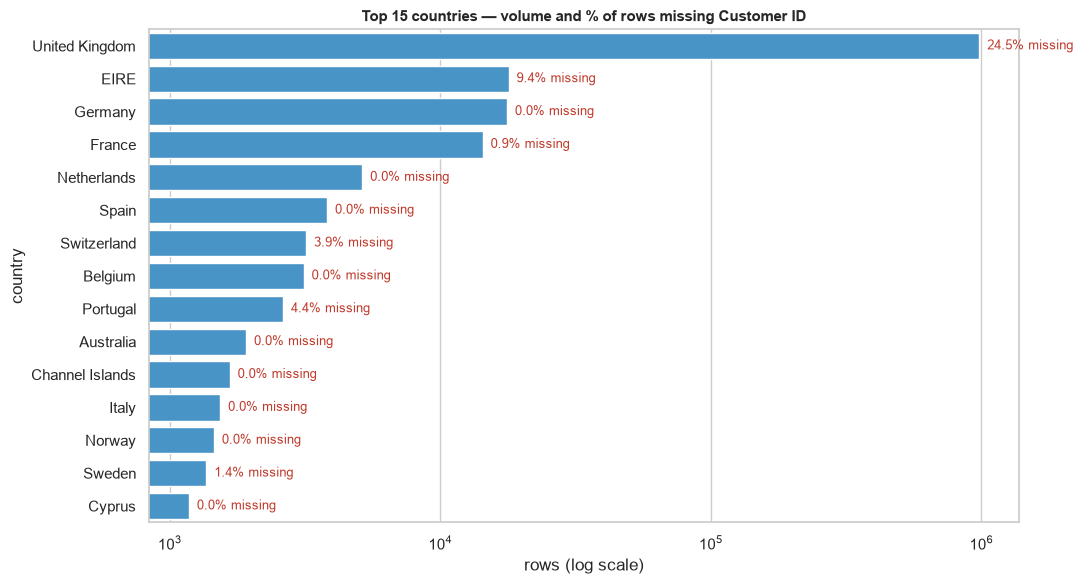

In [7]:
top = by_country.head(15).reset_index()
fig, ax = plt.subplots(figsize=(11, 6))
sns.barplot(data=top, y="country", x="n_rows", ax=ax, color="#3498db")
ax.set_xscale("log")
ax.set_xlabel("rows (log scale)")
ax.set_title("Top 15 countries — volume and % of rows missing Customer ID")
for i, row in top.iterrows():
    ax.text(
        row["n_rows"], i, f"  {row['pct_missing']:.1f}% missing",
        va="center", color="#c0392b", fontsize=9,
    )
plt.tight_layout()
plt.show()

### 4.2 Association test: country vs missingness

In [8]:
ct = pd.crosstab(raw["country"], raw["missing_customer"])
chi2, p_value, dof, _ = stats.chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"Chi-square test (country vs missing Customer ID)")
print(f"  chi2={chi2:,.0f} | dof={dof} | p={p_value:.3g} | Cramer's V={cramers_v:.3f}")
print("  -> a tiny p-value indicates missingness is NOT independent of country")

Chi-square test (country vs missing Customer ID)
  chi2=23,346 | dof=42 | p=0 | Cramer's V=0.148
  -> a tiny p-value indicates missingness is NOT independent of country


### 4.3 Do missing-customer rows differ behaviourally?

If the missing rows have a different cancellation rate, revenue distribution or
basket size, then the missingness carries information — it is **not** MCAR.

In [9]:
summary = raw.groupby("missing_customer").agg(
    rows=("missing_customer", "size"),
    cancellation_rate=("is_cancellation", "mean"),
    negative_line_rate=("line_revenue", lambda s: float((s < 0).mean())),
    mean_line_revenue=("line_revenue", "mean"),
    median_line_revenue=("line_revenue", "median"),
    mean_quantity=("quantity", "mean"),
    median_unit_price=("unit_price", "median"),
)
summary.index = ["Customer ID present", "Customer ID missing"]
summary

,rows,cancellation_rate,negative_line_rate,mean_line_revenue,median_line_revenue,mean_quantity,median_unit_price
Customer ID present,824364,0.02,0.02,20.20,11.25,12.41,1.95
Customer ID missing,243007,0.00,0.00,10.86,4.98,1.54,3.29


Mann-Whitney U (line revenue, missing vs present): U=69,440,516,917, p=0
median line revenue | missing=4.98 | present=11.25


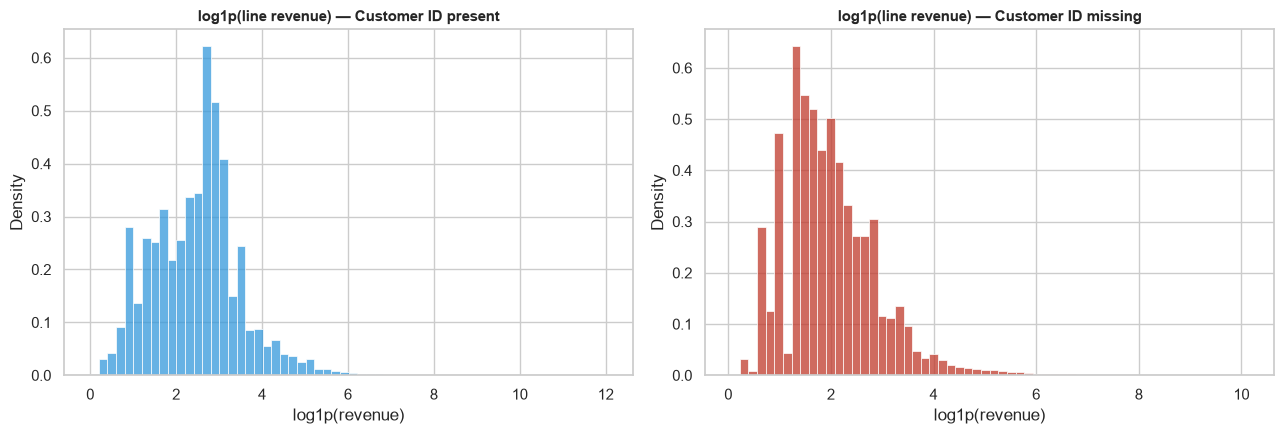

In [10]:
rev_present = raw.loc[~raw["missing_customer"], "line_revenue"].dropna()
rev_missing = raw.loc[raw["missing_customer"], "line_revenue"].dropna()
u_stat, p_u = stats.mannwhitneyu(rev_missing, rev_present, alternative="two-sided")
print(f"Mann-Whitney U (line revenue, missing vs present): U={u_stat:,.0f}, p={p_u:.3g}")
print(f"median line revenue | missing={rev_missing.median():,.2f} | present={rev_present.median():,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(np.log1p(rev_present[rev_present > 0]), bins=60, ax=axes[0],
             color="#3498db", stat="density")
axes[0].set_title("log1p(line revenue) — Customer ID present")
axes[0].set_xlabel("log1p(revenue)")
sns.histplot(np.log1p(rev_missing[rev_missing > 0]), bins=60, ax=axes[1],
             color="#c0392b", stat="density")
axes[1].set_title("log1p(line revenue) — Customer ID missing")
axes[1].set_xlabel("log1p(revenue)")
plt.tight_layout()
plt.show()

### 4.4 Is missingness time-dependent?

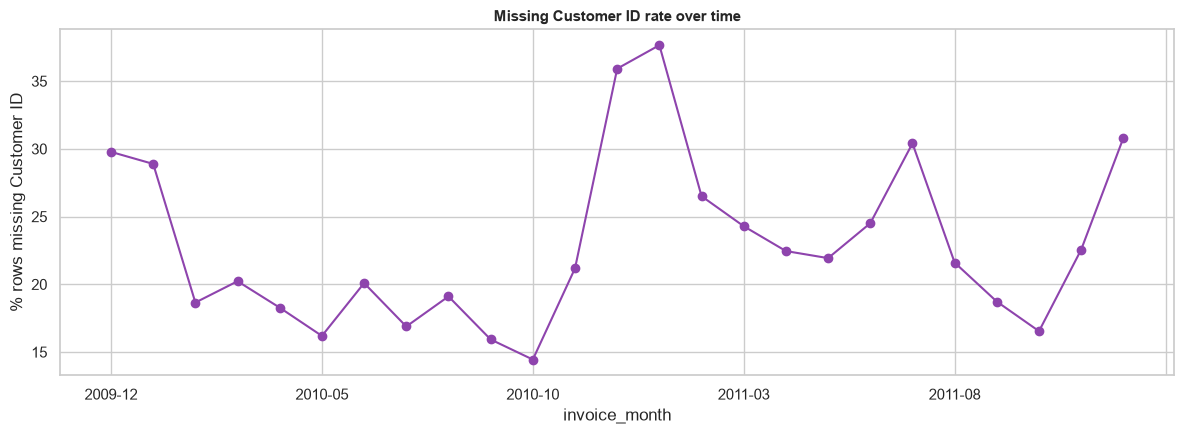

,n_rows,pct_missing
invoice_month,,
2011-08,35284,21.60
2011-09,50226,18.72
2011-10,60742,16.54
2011-11,84711,22.56
2011-12,25526,30.81


In [11]:
by_month = raw.groupby("invoice_month").agg(
    n_rows=("missing_customer", "size"),
    pct_missing=("missing_customer", "mean"),
)
by_month["pct_missing"] *= 100
ax = by_month["pct_missing"].plot(figsize=(12, 4.5), marker="o", color="#8e44ad")
ax.set_ylabel("% rows missing Customer ID")
ax.set_title("Missing Customer ID rate over time")
plt.tight_layout()
plt.show()
by_month.tail()

### 4.5 Interpretation — the missingness is **MNAR**

The evidence points away from MCAR:

- Missing-customer rows contain **no cancellations at all** (0% vs ~2% for
  identified rows) and have **far smaller baskets** — median line revenue
  £4.98 vs £11.25, mean quantity 1.5 vs 12.4 units.
- The **revenue distributions differ significantly** (Mann-Whitney p ≈ 0).
- Missingness is strongly associated with **country** (chi-square p ≈ 0) and
  varies over **time**.

Crucially, the missing field is the *customer identity* itself. Anonymous /
guest purchases are structurally different from identified purchases — they
cannot be tied to a repeat-purchase history by definition. The probability of
missingness therefore depends on the very thing that is missing (who the
customer is, and whether they have an account), which is the definition of
**MNAR**.

**Consequences for the platform**

1. Dropping missing-customer rows (as the ingestion pipeline does) is the
   correct choice for a *customer-level* churn model — those rows have no
   owner to score.
2. The dropped rows are **not** a random sample, so all customer-level
   statistics are conditional on "identified customer". This is a documented
   limitation, not something to hide.
3. Guest transactions still inflate *company* revenue, so they are retained in
   company-level reporting (`transactions_raw`, monthly summary) but excluded
   from customer features.

### 4.6 Other missing fields — `Description`

`Description` is the only other column with missing values (0.41%). Unlike
`Customer ID`, we can test whether its missingness is fully explained by an
**observed** variable (`stock_code`), which would make it **MAR** rather than
MNAR.

In [12]:
desc_missing = raw["description"].isna()
print(f"Description missing: {int(desc_missing.sum()):,} rows ({desc_missing.mean()*100:.2f}%)")

top_codes = raw.loc[desc_missing, "stock_code"].value_counts().head(10)
top_codes_share = top_codes.sum() / desc_missing.sum() * 100
print(f"distinct stock codes affected         : {raw.loc[desc_missing, 'stock_code'].nunique()}")
print(f"share of missing rows in top 10 codes : {top_codes_share:.1f}%")
print("\nTop stock codes with missing description:")
print(top_codes)

# Does missingness depend on anything other than stock_code?
print("\nCancellation rate | description missing :", f"{raw.loc[desc_missing, 'is_cancellation'].mean()*100:.2f}%")
print("Cancellation rate | description present :", f"{raw.loc[~desc_missing, 'is_cancellation'].mean()*100:.2f}%")
print("\nMean quantity | description missing :", f"{raw.loc[desc_missing, 'quantity'].mean():.2f}")
print("Mean quantity | description present :", f"{raw.loc[~desc_missing, 'quantity'].mean():.2f}")

Description missing: 4,382 rows (0.41%)
distinct stock codes affected         : 2451
share of missing rows in top 10 codes : 2.3%

Top stock codes with missing description:
stock_code
84990    12
22139    12
35965    11
79321    11
22950    10
23084    10
22084     9
22087     9
71477     8
37461     8
Name: count, dtype: Int64

Cancellation rate | description missing : 0.00%
Cancellation rate | description present : 1.83%

Mean quantity | description missing : -17.26
Mean quantity | description present : 10.05


**Verdict:**

- `Customer ID` → **MNAR**: missingness is driven by *who the customer is*
  (anonymous vs identified), which is precisely the value that is missing.
  Dropping these rows is required for customer-level modelling and is a
  documented bias.
- `Description` → **not MCAR, but effectively harmless**: it is spread thinly
  across 2,451 stock codes (the top 10 account for only 2.3%), correlates with
  no cancellations (0% vs 1.8%), and affects just 0.41% of rows. It is not used
  as a model feature, so we neither impute nor drop on it.

## 5. Distributions — transaction level

In [13]:
num_cols = ["quantity", "unit_price", "line_revenue"]
desc = clean[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
desc["skew"] = clean[num_cols].skew()
desc["kurtosis"] = clean[num_cols].kurtosis()
desc

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew,kurtosis
quantity,"808,723.00",12.61,190.74,"-80,995.00",-2.00,1.00,2.00,5.00,12.00,36.00,128.00,"80,995.00",5.03,"137,442.01"
unit_price,"808,723.00",2.98,4.63,0.00,0.29,0.42,1.25,1.95,3.75,8.50,12.75,649.50,33.11,"2,354.41"
line_revenue,"808,723.00",20.60,303.35,"-168,469.60",-9.95,1.10,4.25,11.70,19.50,66.00,198.00,"168,469.60",2.88,"245,961.11"


### 5.1 Quantity

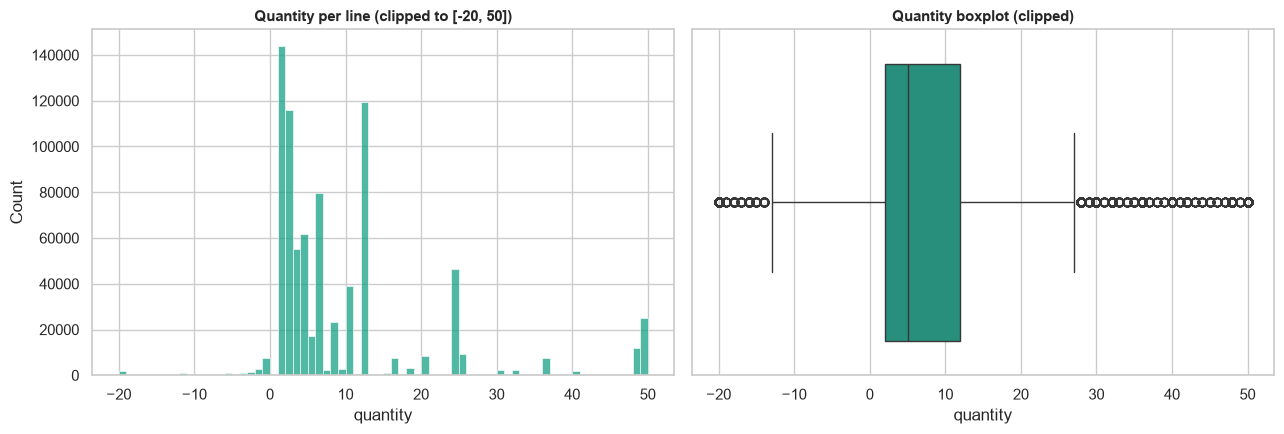

negative quantity lines : 17,911 (2.21%)
zero quantity lines     : 0


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(clean["quantity"].clip(-20, 50), bins=70, ax=axes[0], color="#16a085")
axes[0].set_title("Quantity per line (clipped to [-20, 50])")
axes[0].set_xlabel("quantity")
sns.boxplot(x=clean["quantity"].clip(-20, 50), ax=axes[1], color="#16a085")
axes[1].set_title("Quantity boxplot (clipped)")
plt.tight_layout()
plt.show()

print(f"negative quantity lines : {int((clean['quantity'] < 0).sum()):,} ({(clean['quantity'] < 0).mean()*100:.2f}%)")
print(f"zero quantity lines     : {int((clean['quantity'] == 0).sum()):,}")

### 5.2 Unit price

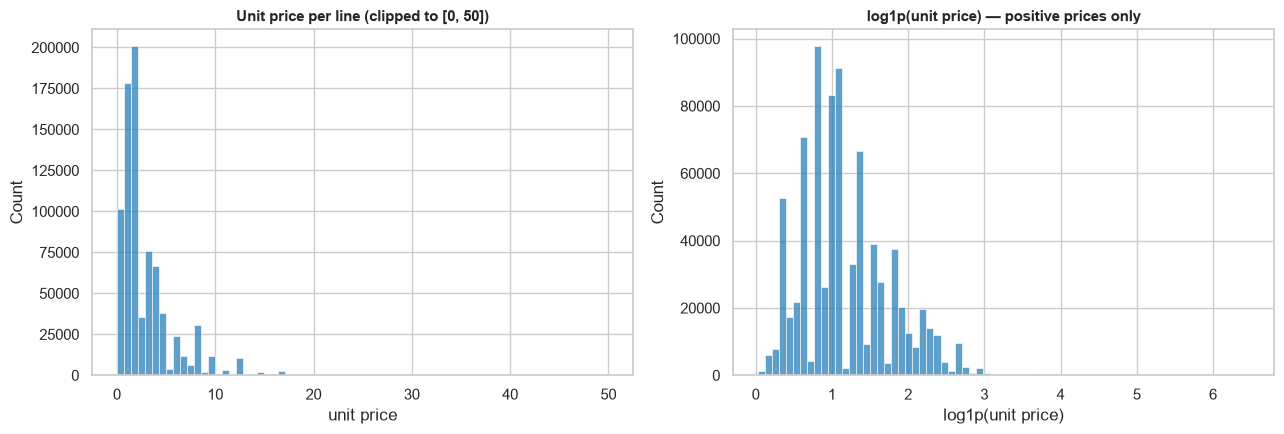

zero/negative price lines : 63 (0.01%)


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(clean["unit_price"].clip(0, 50), bins=70, ax=axes[0], color="#2980b9")
axes[0].set_title("Unit price per line (clipped to [0, 50])")
axes[0].set_xlabel("unit price")
sns.histplot(np.log1p(clean.loc[clean["unit_price"] > 0, "unit_price"]), bins=70,
             ax=axes[1], color="#2980b9")
axes[1].set_title("log1p(unit price) — positive prices only")
axes[1].set_xlabel("log1p(unit price)")
plt.tight_layout()
plt.show()

print(f"zero/negative price lines : {int((clean['unit_price'] <= 0).sum()):,} ({(clean['unit_price'] <= 0).mean()*100:.2f}%)")

### 5.3 Line revenue

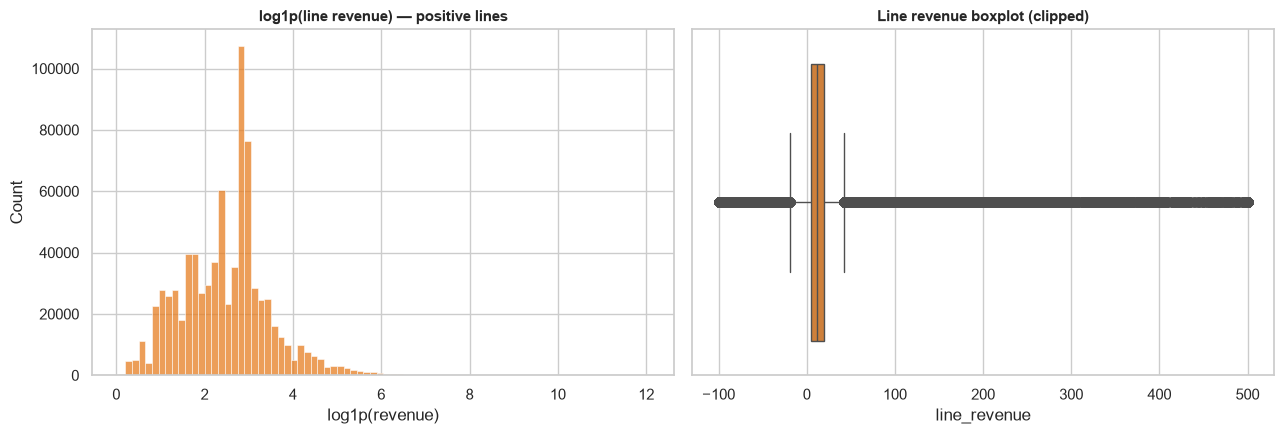

line revenue skew (positive lines): 595.57
top 1% of positive lines hold 22.6% of gross revenue


In [16]:
pos_rev = clean.loc[clean["line_revenue"] > 0, "line_revenue"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(np.log1p(pos_rev), bins=80, ax=axes[0], color="#e67e22")
axes[0].set_title("log1p(line revenue) — positive lines")
axes[0].set_xlabel("log1p(revenue)")
sns.boxplot(x=clean["line_revenue"].clip(-100, 500), ax=axes[1], color="#e67e22")
axes[1].set_title("Line revenue boxplot (clipped)")
plt.tight_layout()
plt.show()

print(f"line revenue skew (positive lines): {pos_rev.skew():.2f}")
top_1pct_share = pos_rev.nlargest(int(len(pos_rev) * 0.01)).sum() / pos_rev.sum() * 100
print(f"top 1% of positive lines hold {top_1pct_share:.1f}% of gross revenue")

### 5.4 Top products

In [17]:
purchases = clean.loc[~clean["is_cancellation"]]
top_products = (
    purchases.groupby(["stock_code", "description"], dropna=False)
    .agg(revenue=("line_revenue", "sum"), units=("quantity", "sum"), orders=("invoice_no", "nunique"))
    .sort_values("revenue", ascending=False)
    .head(15)
)
top_products

,,revenue,units,orders
stock_code,description,,,
22423,REGENCY CAKESTAND 3 TIER,"285,992.35",24873,3318
85123A,WHITE HANGING HEART T-LIGHT HOLDER,"251,731.26",93520,4888
23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1
85099B,JUMBO BAG RED RETROSPOT,"136,684.79",75597,2612
84879,ASSORTED COLOUR BIRD ORNAMENT,"126,704.06",79694,2652
47566,PARTY BUNTING,"103,802.53",23595,2078
23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,416.73",77916,195
22086,PAPER CHAIN KIT 50'S CHRISTMAS,"79,455.68",29430,1691
79321,CHILLI LIGHTS,"72,527.79",15658,922


### 5.5 Outliers and data anomalies

Extreme single transactions can dominate aggregates. The Online Retail II
dataset in particular contains a known anomalous bulk order (and its matching
cancellation) that must be handled by robust feature engineering.

In [18]:
largest_orders = (
    clean.groupby("invoice_no")
    .agg(revenue=("line_revenue", "sum"), quantity=("quantity", "sum"),
         lines=("invoice_no", "size"), customer=("customer_id", "first"))
    .sort_values("revenue", ascending=False)
    .head(5)
)
print("Largest orders by net revenue:")
largest_orders

Largest orders by net revenue:


,revenue,quantity,lines,customer
invoice_no,,,,
581483,"168,469.60",80995,1,16446
541431,"77,183.60",74215,1,12346
493819,"44,051.60",25018,94,14156
556444,"38,970.00",60,1,15098
524181,"33,167.80",8820,14,17450


In [19]:
top_qty = clean.assign(abs_qty=clean["quantity"].abs()).nlargest(5, "abs_qty")[
    ["invoice_no", "stock_code", "description", "quantity", "unit_price", "line_revenue", "customer_id"]
]
print("Largest absolute-quantity lines (the ~81k pair is the known anomaly):")
top_qty

Largest absolute-quantity lines (the ~81k pair is the known anomaly):


,invoice_no,stock_code,description,quantity,unit_price,line_revenue,customer_id
808256,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,"168,469.60",16446
808257,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08,"-168,469.60",16446
446374,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,"77,183.60",12346
446379,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04,"-77,183.60",12346
64221,497946,37410,BLACK AND WHITE PAISLEY FLOWER MUG,19152,0.10,"1,915.20",13902


## 6. Distributions — geography and time

### 6.1 Geography

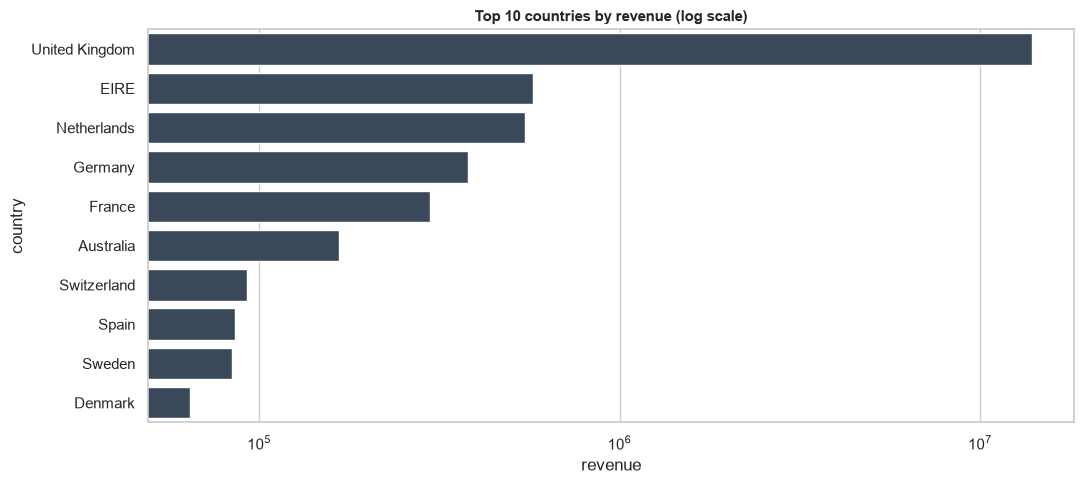

United Kingdom revenue share: 83.6%


,customers,revenue,orders,revenue_share_%,cum_share_%
country,,,,,
United Kingdom,5369,"13,933,030.78",39903,83.62,83.62
EIRE,5,"573,549.78",672,3.44,87.06
Netherlands,23,"546,254.65",229,3.28,90.34
Germany,107,"379,397.03",1041,2.28,92.62
France,94,"297,434.07",702,1.78,94.40
Australia,15,"166,899.30",108,1.00,95.40
Switzerland,22,"92,517.81",108,0.56,95.96
Spain,41,"85,807.78",172,0.51,96.47
Sweden,19,"84,071.17",113,0.50,96.97


In [20]:
country = (
    clean.groupby("country")
    .agg(customers=("customer_id", "nunique"), revenue=("line_revenue", "sum"),
         orders=("invoice_no", "nunique"))
    .sort_values("revenue", ascending=False)
)
country["revenue_share_%"] = (country["revenue"] / country["revenue"].sum() * 100).round(2)
country["cum_share_%"] = country["revenue_share_%"].cumsum().round(2)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=country.head(10).reset_index(), y="country", x="revenue", ax=ax, color="#34495e")
ax.set_xscale("log")
ax.set_title("Top 10 countries by revenue (log scale)")
plt.tight_layout()
plt.show()

print(f"United Kingdom revenue share: {country.loc['United Kingdom', 'revenue_share_%']:.1f}%")
country.head(10)

### 6.2 Temporal patterns

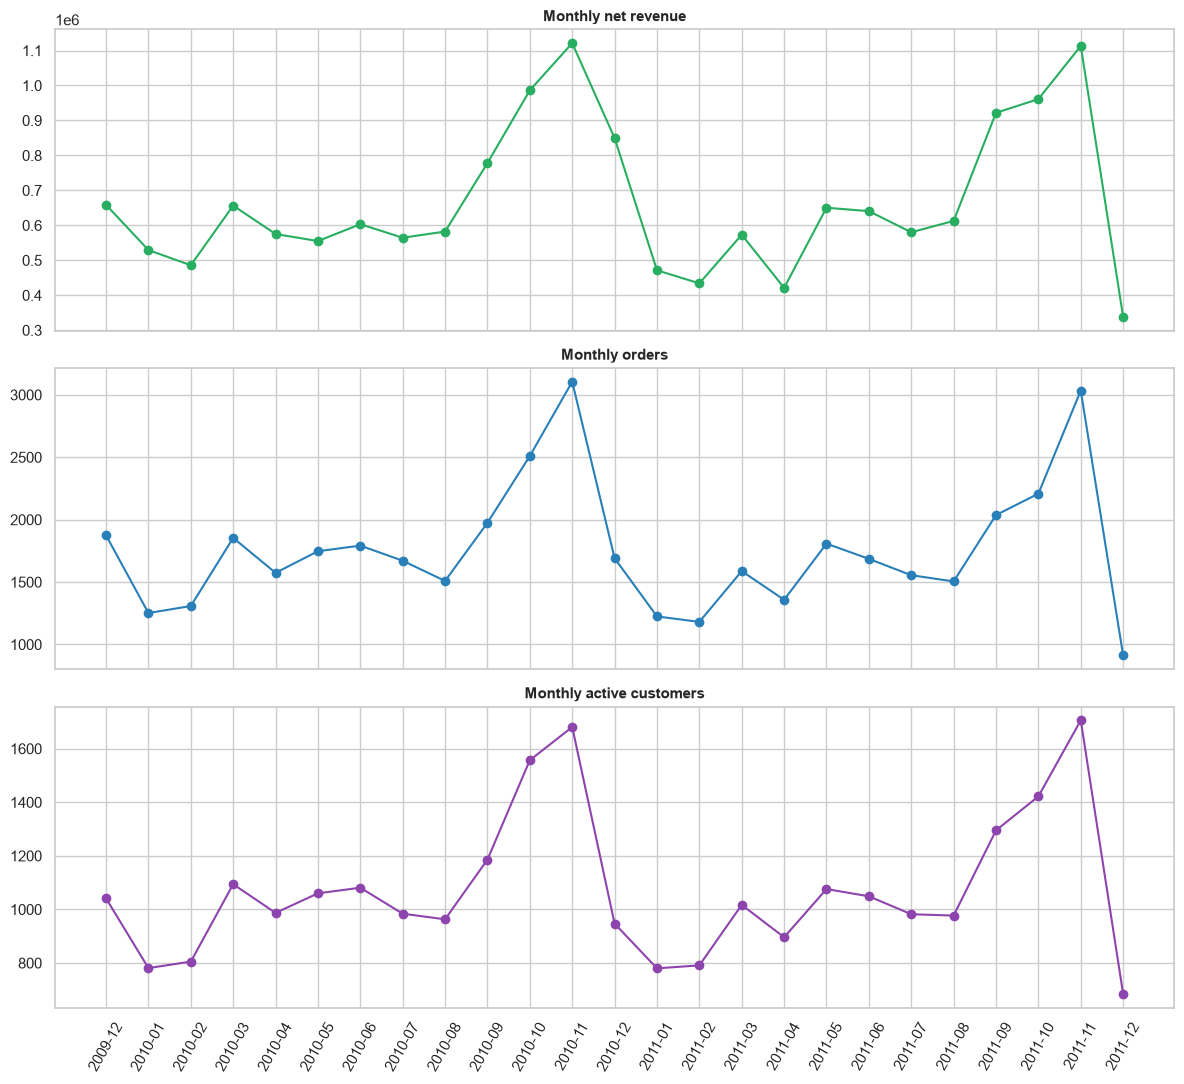

In [21]:
monthly = (
    clean.groupby("invoice_month")
    .agg(net_revenue=("line_revenue", "sum"), orders=("invoice_no", "nunique"),
         customers=("customer_id", "nunique"), cancellations=("is_cancellation", "sum"))
    .reset_index()
)
fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=True)
axes[0].plot(monthly["invoice_month"], monthly["net_revenue"], marker="o", color="#27ae60")
axes[0].set_title("Monthly net revenue")
axes[1].plot(monthly["invoice_month"], monthly["orders"], marker="o", color="#2980b9")
axes[1].set_title("Monthly orders")
axes[2].plot(monthly["invoice_month"], monthly["customers"], marker="o", color="#8e44ad")
axes[2].set_title("Monthly active customers")
for ax in axes:
    ax.tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

### 6.3 Cancellations / returns over time

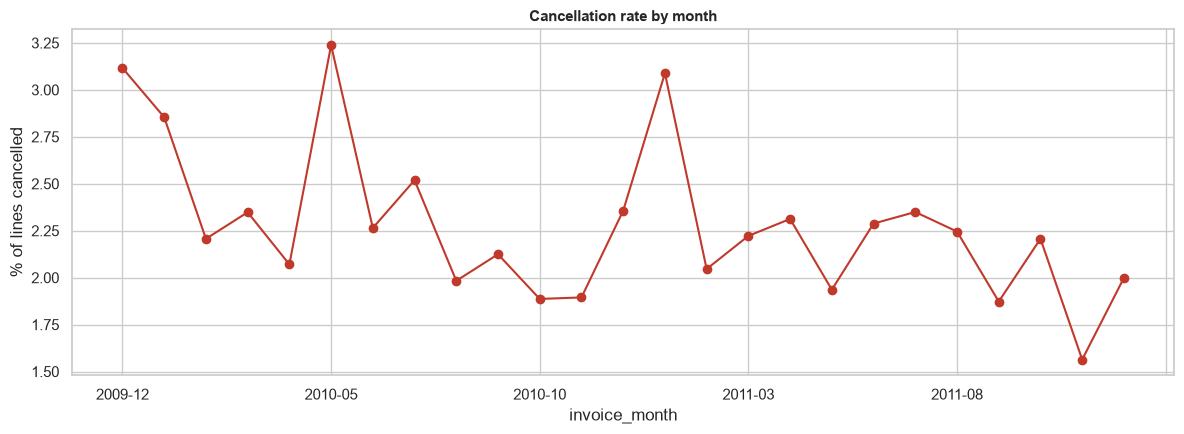

Overall cancellation line rate: 2.21%


In [22]:
canc = clean.groupby("invoice_month").agg(
    cancellations=("is_cancellation", "sum"), lines=("is_cancellation", "size"))
canc["cancel_rate_%"] = canc["cancellations"] / canc["lines"] * 100
ax = canc["cancel_rate_%"].plot(figsize=(12, 4.5), marker="o", color="#c0392b")
ax.set_ylabel("% of lines cancelled")
ax.set_title("Cancellation rate by month")
plt.tight_layout()
plt.show()
print(f"Overall cancellation line rate: {clean['is_cancellation'].mean()*100:.2f}%")

## 7. Distributions — customer level

These are the quantities the churn and CLV models will ultimately reason about.

In [23]:
max_date = clean["invoice_date"].max()
cust = (
    purchases.groupby("customer_id")
    .agg(
        n_orders=("invoice_no", "nunique"),
        n_lines=("invoice_no", "size"),
        total_revenue=("line_revenue", "sum"),
        first_purchase=("invoice_date", "min"),
        last_purchase=("invoice_date", "max"),
    )
    .reset_index()
)
cust["aov"] = cust["total_revenue"] / cust["n_orders"]
cust["tenure_days"] = (cust["last_purchase"] - cust["first_purchase"]).dt.days
cust["recency_days"] = (max_date - cust["last_purchase"]).dt.days
print(f"customers: {len(cust):,}")
cust.head()

customers: 5,864


,customer_id,n_orders,n_lines,total_revenue,first_purchase,last_purchase,aov,tenure_days,recency_days
0,12346,12,34,"77,556.46",2009-12-14 08:34:00,2011-01-18 10:01:00,"6,463.04",400,325
1,12347,8,253,"5,633.32",2010-10-31 14:20:00,2011-12-07 15:52:00,704.16,402,1
2,12348,5,46,"1,658.40",2010-09-27 14:59:00,2011-09-25 13:13:00,331.68,362,74
3,12349,3,172,"3,678.69",2010-04-29 13:20:00,2011-11-21 09:51:00,"1,226.23",570,18
4,12350,1,16,294.40,2011-02-02 16:01:00,2011-02-02 16:01:00,294.40,0,309


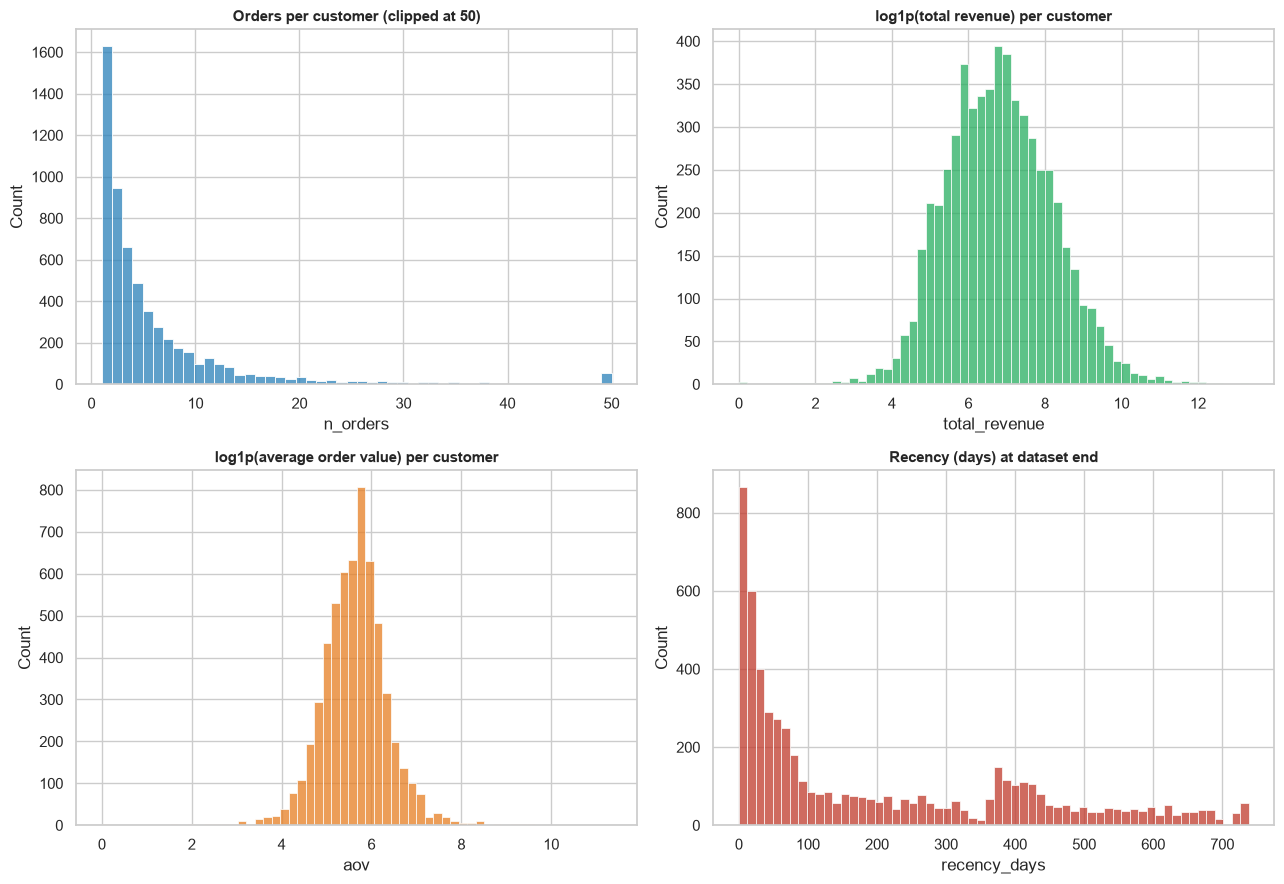

,count,mean,std,min,25%,50%,75%,max
n_orders,"5,864.00",6.25,12.77,1.00,1.00,3.00,7.00,376.00
total_revenue,"5,864.00","2,964.08","14,589.14",0.00,341.43,873.34,"2,278.79","608,821.65"
aov,"5,864.00",385.12,"1,212.11",0.00,178.35,281.62,416.43,"84,236.25"
recency_days,"5,864.00",200.06,209.34,0.00,25.00,95.00,378.00,738.00
tenure_days,"5,864.00",273.06,258.53,0.00,0.00,221.00,511.00,738.00


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
sns.histplot(cust["n_orders"].clip(upper=50), bins=50, ax=axes[0, 0], color="#2980b9")
axes[0, 0].set_title("Orders per customer (clipped at 50)")
sns.histplot(np.log1p(cust["total_revenue"].clip(lower=0)), bins=60, ax=axes[0, 1], color="#27ae60")
axes[0, 1].set_title("log1p(total revenue) per customer")
sns.histplot(np.log1p(cust["aov"].clip(lower=0)), bins=60, ax=axes[1, 0], color="#e67e22")
axes[1, 0].set_title("log1p(average order value) per customer")
sns.histplot(cust["recency_days"], bins=60, ax=axes[1, 1], color="#c0392b")
axes[1, 1].set_title("Recency (days) at dataset end")
plt.tight_layout()
plt.show()
cust[["n_orders", "total_revenue", "aov", "recency_days", "tenure_days"]].describe().T

### 7.1 Revenue concentration (Pareto)

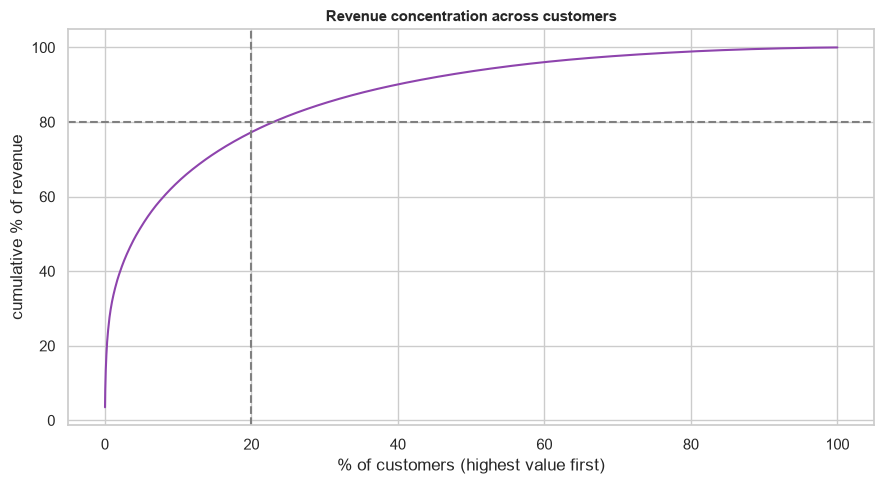

Top 20% of customers hold 77.3% of revenue


In [25]:
rev_sorted = cust["total_revenue"].sort_values(ascending=False).reset_index(drop=True)
cum_share = rev_sorted.cumsum() / rev_sorted.sum()
pct_customers = np.arange(1, len(rev_sorted) + 1) / len(rev_sorted)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pct_customers * 100, cum_share * 100, color="#8e44ad")
ax.axhline(80, color="grey", ls="--")
ax.axvline(20, color="grey", ls="--")
ax.set_xlabel("% of customers (highest value first)")
ax.set_ylabel("cumulative % of revenue")
ax.set_title("Revenue concentration across customers")
plt.tight_layout()
plt.show()

print(f"Top 20% of customers hold {cum_share.iloc[int(len(cum_share) * 0.2) - 1] * 100:.1f}% of revenue")

### 7.2 Return behaviour per customer

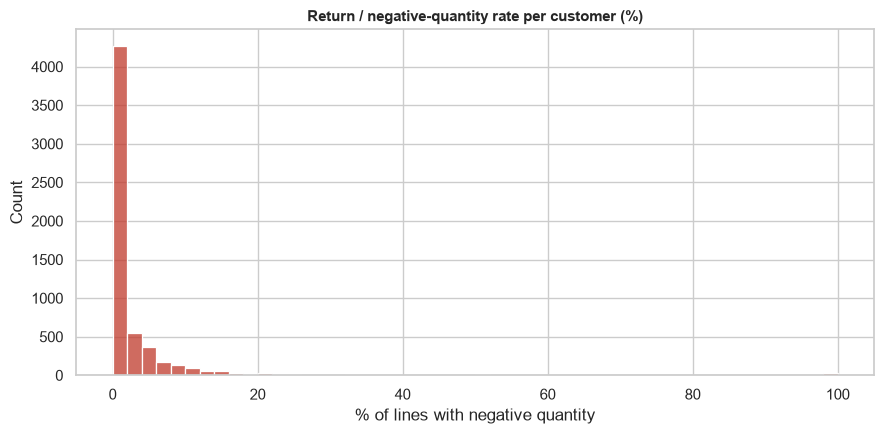

customers with >20% return rate: 149 (2.5%)


In [26]:
ret = clean.assign(is_negative=clean["quantity"] < 0).groupby("customer_id")["is_negative"].mean() * 100
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.histplot(ret, bins=50, ax=ax, color="#c0392b")
ax.set_title("Return / negative-quantity rate per customer (%)")
ax.set_xlabel("% of lines with negative quantity")
plt.tight_layout()
plt.show()
print(f"customers with >20% return rate: {int((ret > 20).sum()):,} ({(ret > 20).mean()*100:.1f}%)")

## 8. Key findings & implications

In [27]:
uk_share = country.loc["United Kingdom", "revenue_share_%"]
top20_share = cum_share.iloc[int(len(cum_share) * 0.2) - 1] * 100
findings = {
    "raw rows": f"{len(raw):,}",
    "clean rows": f"{len(clean):,}",
    "rows dropped (no customer / admin / dupes)": f"{len(raw) - len(clean):,}",
    "missing Customer ID share": f"{raw['customer_id'].isna().mean()*100:.2f}%",
    "customers": f"{clean['customer_id'].nunique():,}",
    "countries": f"{clean['country'].nunique()}",
    "UK revenue share": f"{uk_share:.1f}%",
    "cancellation line rate": f"{clean['is_cancellation'].mean()*100:.2f}%",
    "top 20% customers revenue share": f"{top20_share:.1f}%",
    "line revenue skew (positive lines)": f"{pos_rev.skew():.2f}",
}
for k, v in findings.items():
    print(f"{k:<45s}: {v}")

raw rows                                     : 1,067,371
clean rows                                   : 808,723
rows dropped (no customer / admin / dupes)   : 258,648
missing Customer ID share                    : 22.77%
customers                                    : 5,897
countries                                    : 41
UK revenue share                             : 83.6%
cancellation line rate                       : 2.21%
top 20% customers revenue share              : 77.3%
line revenue skew (positive lines)           : 595.57


### What this means for the platform

1. **MNAR is real and material.** ~1 in 4–5 rows (23%) has no `Customer ID`, and
   those rows are behaviourally different (much smaller baskets, different
   revenue distribution, uneven by country and time). They are
   excluded from customer-level modelling, and this conditional sample is a
   documented limitation.
2. **Heavy right skew everywhere.** Line revenue, customer revenue and order
   counts are extremely skewed and long-tailed. The model needs log transforms
   and/or tree-based methods; robust (median/IQR) summaries matter more than
   means.
3. **Extreme outliers exist.** A handful of transactions (notably an ~81k-unit
   bulk order and its matching cancellation) dominate raw sums. Feature
   engineering must winsorise or otherwise handle these robustly.
3. **Value is concentrated.** A small fraction of customers drives most
   revenue, which is exactly why prioritisation must weight churn probability by
   CLV rather than treating all churners equally.
4. **Returns are a first-class signal.** Cancellations and negative quantities
   are common enough to justify explicit `return_rate` / cancellation features,
   and they behave differently across customers.
5. **Strong seasonality.** Revenue and active-customer counts peak around
   October–November and collapse in December/January — features must be
   *relative* (recent activity vs. baseline) to avoid mistaking seasonality for
   churn.
6. **Geography is concentrated.** The UK dominates revenue, so country should be
   a categorical feature and results should be interpreted with the UK bias in
   mind.
7. **Temporal validity is non-negotiable.** Given the clear time structure, the
   churn label and features must use an observation → performance window split
   (as designed) — never random splits.